In [1]:
import sys
sys.path.insert(0, '..')

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as sp_stats

from src.metrics.limit_cycles import (
    detect_agent_limit_cycles,
    detect_system_limit_cycles,
    summarise_lc,
    _recurrence_matrix,
    _det,
    _diagonalwise_rr,
)

BASE     = Path('..') / 'results' / 'mas' / 'final_dataset'
W_VALUES = [1, 2, 5]
TOPOS    = ['fc', 'star']
DATASETS = ['gpqa', 'hiddenbench']

W_COLORS  = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
DS_COLORS = {'gpqa': '#5470C6', 'hiddenbench': '#EE6666'}
T_COLORS  = {'fc': '#2c7bb6', 'star': '#d7191c'}
DS_LABELS = {'gpqa': 'GPQA', 'hiddenbench': 'HiddenBench'}
T_LABELS  = {'fc': 'Full-connected', 'star': 'Star'}

/Users/I550854/Documents/Master Thesis/self-organization-mas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data & Run Detectors

For each file: run **agent-level** and **system-level** RQA detection.
Surrogates only run on non-converged candidates (trailing-run < 3), so this is fast despite B=1000.

In [2]:
agent_rows = []
sys_rows   = []

t0   = time.time()
opts = ('A', 'B', 'C', 'D')

for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W    = d['W']
    ds   = d['dataset']
    topo = d.get('topology_name', 'fc')
    qid  = d['question_id']
    gt   = d['ground_truth']
    reps = d['repetitions']

    for row in detect_agent_limit_cycles(reps, B=1000, seed=0):
        traj = reps[row['rep_idx']]['trajectory']
        seq  = [traj[t]['phase_b'][row['agent_idx']]['vote']
                for t in range(len(traj))]
        agent_rows.append({'W': W, 'dataset': ds, 'topology': topo,
                           'qid': qid, 'ground_truth': gt, 'seq': seq, **row})

    for row in detect_system_limit_cycles(reps, B=1000, seed=0):
        traj = reps[row['rep_idx']]['trajectory']
        # store as composition counts (n_A, n_B, n_C, n_D) — ints, not vote strings
        seq  = [tuple(sum(ag['vote'] == o for ag in traj[t]['phase_b']) for o in opts)
                for t in range(len(traj))]
        sys_rows.append({'W': W, 'dataset': ds, 'topology': topo,
                         'qid': qid, 'ground_truth': gt, 'seq': seq, **row})

elapsed = time.time() - t0
agent_df = pd.DataFrame(agent_rows)
sys_df   = pd.DataFrame(sys_rows)
print(f'Done in {elapsed:.1f}s')
print(f'Agent rows : {len(agent_df):,}')
print(f'System rows: {len(sys_df):,}')

Done in 47.1s
Agent rows : 50,400
System rows: 12,600


---
## Part 1 — Accounting Funnel

How many sequences survive each filter stage:
`total → fixed-point → candidates → flagged`

In [3]:
def funnel(df, label):
    n_total = len(df)
    n_fp    = int(df['fixed_point'].sum())
    n_cand  = int((~df['fixed_point'] & (df['L'] >= 4)).sum())
    n_flag  = int(df['lc'].sum())
    p_lc    = n_flag / n_cand if n_cand > 0 else float('nan')
    sep = '─' * 58
    print(sep)
    print(label)
    print(sep)
    print(f'  Total sequences           : {n_total:>7,}')
    print(f'  Fixed points (k >= 3)     : {n_fp:>7,}  ({100*n_fp/n_total:.2f}%)')
    print(f'  Candidates (k < 3, L >= 4): {n_cand:>7,}  ({100*n_cand/n_total:.2f}%)')
    print(f'  Flagged (p < 0.05)        : {n_flag:>7,}  ({100*n_flag/n_total:.2f}% of total)')
    if not np.isnan(p_lc):
        print(f'  p_LC among candidates     :   {p_lc:.4f}')
    else:
        print('  p_LC: n/a (no candidates)')
    print()

funnel(agent_df, 'AGENT-LEVEL (one row per rep x agent)')
funnel(sys_df,   'SYSTEM-LEVEL (one row per repetition)')

──────────────────────────────────────────────────────────
AGENT-LEVEL (one row per rep x agent)
──────────────────────────────────────────────────────────
  Total sequences           :  50,400
  Fixed points (k >= 3)     :  49,896  (99.00%)
  Candidates (k < 3, L >= 4):     500  (0.99%)
  Flagged (p < 0.05)        :      14  (0.03% of total)
  p_LC among candidates     :   0.0280

──────────────────────────────────────────────────────────
SYSTEM-LEVEL (one row per repetition)
──────────────────────────────────────────────────────────
  Total sequences           :  12,600
  Fixed points (k >= 3)     :  12,301  (97.63%)
  Candidates (k < 3, L >= 4):     298  (2.37%)
  Flagged (p < 0.05)        :      16  (0.13% of total)
  p_LC among candidates     :   0.0537



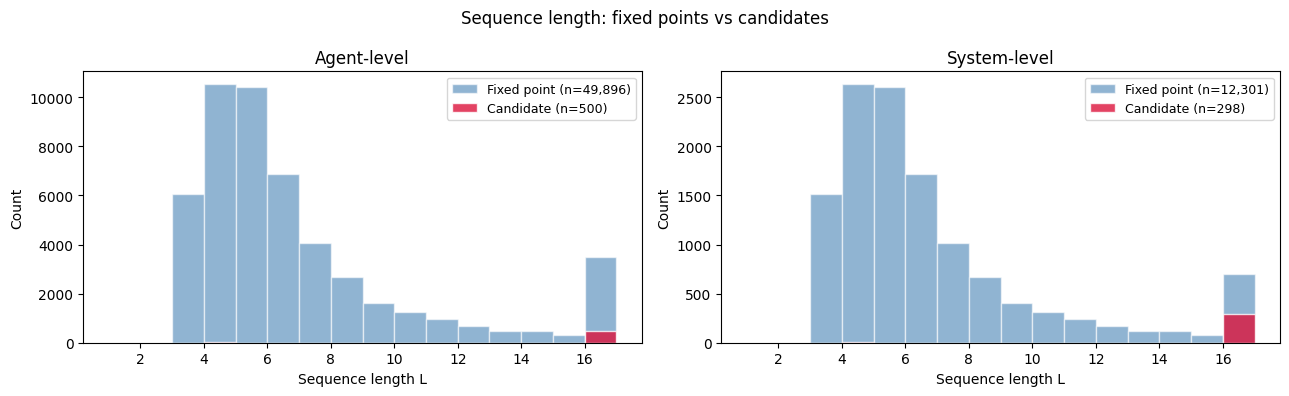

In [4]:
# Sequence length distribution (candidates vs fixed points)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, title in zip(axes,
                         [agent_df, sys_df],
                         ['Agent-level', 'System-level']):
    fp   = df[df['fixed_point']]['L']
    cand = df[~df['fixed_point'] & (df['L'] >= 4)]['L']
    bins = range(1, int(df['L'].max()) + 2)
    ax.hist(fp,   bins=bins, alpha=0.6, label=f'Fixed point (n={len(fp):,})',
            color='steelblue', edgecolor='white')
    ax.hist(cand, bins=bins, alpha=0.8, label=f'Candidate (n={len(cand):,})',
            color='crimson', edgecolor='white')
    ax.set_xlabel('Sequence length L')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend(fontsize=9)

fig.suptitle('Sequence length: fixed points vs candidates', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 2 — Agent-Level: Prevalence by Config

For each (dataset × topology × W): n_total, n_fp, n_candidates, n_flagged, p_LC.

In [5]:
def config_table(df):
    rows = []
    for ds in DATASETS:
        for topo in TOPOS:
            for w in W_VALUES:
                sub  = df[(df['dataset']==ds) & (df['topology']==topo) & (df['W']==w)]
                s    = summarise_lc(sub.to_dict('records'))
                rows.append({
                    'Dataset'   : DS_LABELS[ds],
                    'Topology'  : T_LABELS[topo],
                    'W'         : w,
                    'n_total'   : s['n_total'],
                    'n_fp'      : s['n_fixed_point'],
                    'n_cand'    : s['n_candidates'],
                    'n_flagged' : s['n_flagged'],
                    'p_LC'      : round(s['p_lc'], 4) if not np.isnan(s['p_lc']) else np.nan,
                })
    return pd.DataFrame(rows)

print('=== AGENT-LEVEL ===')
atab = config_table(agent_df)
print(atab.to_string(index=False))
print()
print('=== SYSTEM-LEVEL ===')
stab = config_table(sys_df)
print(stab.to_string(index=False))

=== AGENT-LEVEL ===
    Dataset       Topology  W  n_total  n_fp  n_cand  n_flagged   p_LC
       GPQA Full-connected  1     4200  4185      15          0 0.0000
       GPQA Full-connected  2     4200  4195       5          0 0.0000
       GPQA Full-connected  5     4200  4187      13          1 0.0769
       GPQA           Star  1     4200  4189      11          0 0.0000
       GPQA           Star  2     4200  4182      18          1 0.0556
       GPQA           Star  5     4200  4184      16          0 0.0000
HiddenBench Full-connected  1     4200  4119      81          1 0.0123
HiddenBench Full-connected  2     4200  4142      54          3 0.0556
HiddenBench Full-connected  5     4200  4128      72          0 0.0000
HiddenBench           Star  1     4200  4095     105          1 0.0095
HiddenBench           Star  2     4200  4154      46          1 0.0217
HiddenBench           Star  5     4200  4136      64          6 0.0938

=== SYSTEM-LEVEL ===
    Dataset       Topology  W  n_to

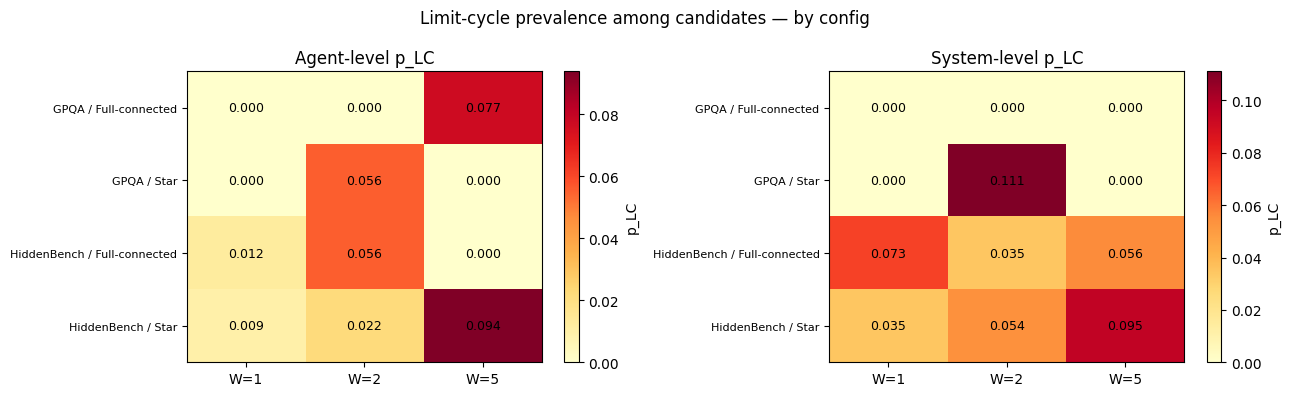

In [6]:
# Heatmap: p_LC per config (agent level)
# Rows: (dataset, topology), Cols: W

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, tab, title in zip(axes,
                           [atab, stab],
                           ['Agent-level p_LC', 'System-level p_LC']):
    pivot = tab.pivot_table(index=['Dataset','Topology'], columns='W', values='p_LC')
    vals  = pivot.values.astype(float)
    # replace nan with -1 for plotting (no candidates)
    display_vals = np.where(np.isnan(vals), -1.0, vals)
    im = ax.imshow(display_vals, aspect='auto', cmap='YlOrRd',
                   vmin=0, vmax=max(0.01, np.nanmax(vals)))
    ax.set_xticks(range(len(W_VALUES)))
    ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{d} / {t}' for d, t in pivot.index], fontsize=8)
    for i in range(len(pivot.index)):
        for j in range(len(W_VALUES)):
            v = vals[i, j]
            txt = f'{v:.3f}' if not np.isnan(v) else 'n/a'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9,
                    color='black' if (np.isnan(v) or v < 0.5) else 'white')
    plt.colorbar(im, ax=ax, label='p_LC')
    ax.set_title(title)

fig.suptitle('Limit-cycle prevalence among candidates — by config', fontsize=12)
plt.tight_layout()
plt.show()

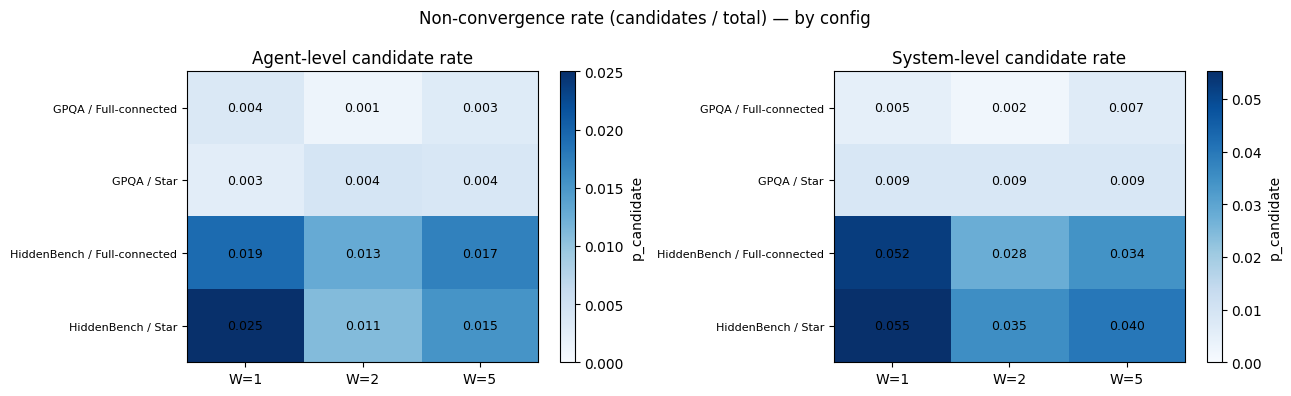

In [7]:
# Candidate rate (not flagged rate) by config — how often does an agent fail to converge?
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, tab, title in zip(axes,
                           [atab, stab],
                           ['Agent-level candidate rate', 'System-level candidate rate']):
    tab2 = tab.copy()
    tab2['p_cand'] = tab2['n_cand'] / tab2['n_total']
    pivot = tab2.pivot_table(index=['Dataset','Topology'], columns='W', values='p_cand')
    vals  = pivot.values.astype(float)
    im = ax.imshow(vals, aspect='auto', cmap='Blues',
                   vmin=0, vmax=max(0.01, np.nanmax(vals)))
    ax.set_xticks(range(len(W_VALUES)))
    ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{d} / {t}' for d, t in pivot.index], fontsize=8)
    for i in range(len(pivot.index)):
        for j in range(len(W_VALUES)):
            ax.text(j, i, f'{vals[i,j]:.3f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax, label='p_candidate')
    ax.set_title(title)

fig.suptitle('Non-convergence rate (candidates / total) — by config', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 3 — DET Scores and Period Distribution

Among candidates: distribution of DET (flagged vs not flagged), and period histogram for flagged cases.

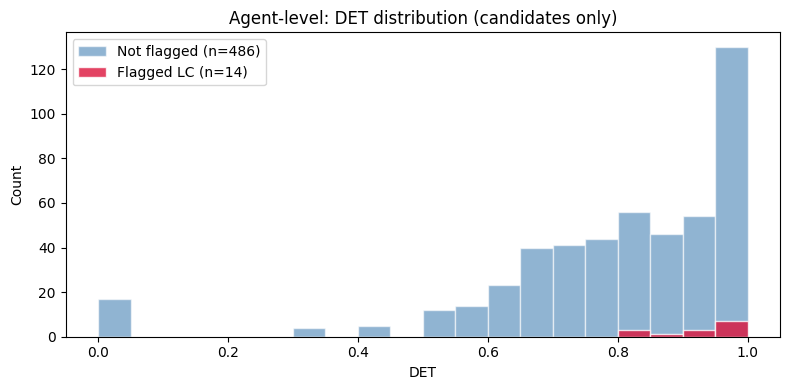

Agent-level: candidates=500, flagged=14
  DET flagged:     mean=0.933  min=0.800  max=1.000
  DET not-flagged: mean=0.795  min=0.000  max=0.990



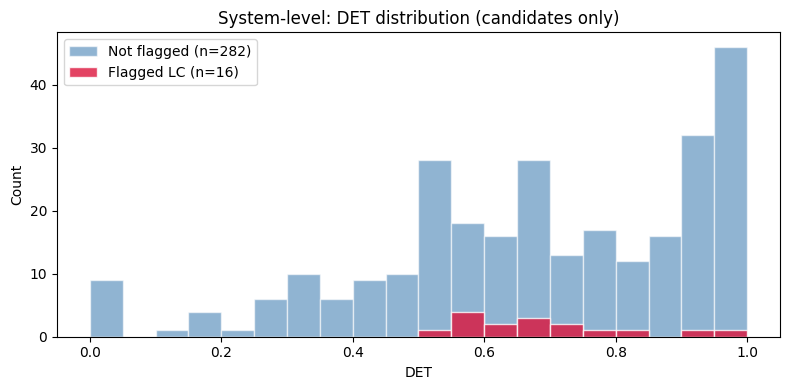

System-level: candidates=298, flagged=16
  DET flagged:     mean=0.690  min=0.500  max=0.957
  DET not-flagged: mean=0.679  min=0.000  max=0.990



In [8]:
# DET score distribution: flagged vs not-flagged candidates
for df, title in [(agent_df, 'Agent-level'), (sys_df, 'System-level')]:
    cands = df[~df['fixed_point'] & (df['L'] >= 4) & df['det'].notna()]
    if len(cands) == 0:
        print(f'{title}: no candidates with DET scores.')
        continue

    flagged    = cands[cands['lc']]['det'].values
    not_flagged= cands[~cands['lc']]['det'].values

    fig, ax = plt.subplots(figsize=(8, 4))
    bins = np.linspace(0, 1, 21)
    if len(not_flagged):
        ax.hist(not_flagged, bins=bins, alpha=0.6, color='steelblue',
                label=f'Not flagged (n={len(not_flagged)})', edgecolor='white')
    if len(flagged):
        ax.hist(flagged, bins=bins, alpha=0.8, color='crimson',
                label=f'Flagged LC (n={len(flagged)})', edgecolor='white')
    ax.set_xlabel('DET')
    ax.set_ylabel('Count')
    ax.set_title(f'{title}: DET distribution (candidates only)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'{title}: candidates={len(cands)}, flagged={len(flagged)}')
    if len(flagged):
        print(f'  DET flagged:     mean={flagged.mean():.3f}  min={flagged.min():.3f}  max={flagged.max():.3f}')
    if len(not_flagged):
        print(f'  DET not-flagged: mean={not_flagged.mean():.3f}  min={not_flagged.min():.3f}  max={not_flagged.max():.3f}')
    print()

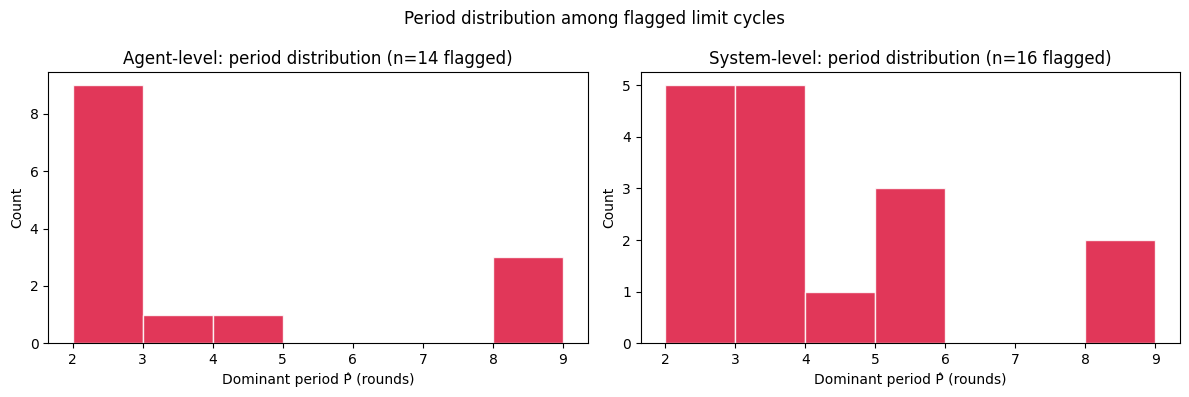

Agent-level flagged: n=14
    dataset topology  W qid  rep_idx  L      det  p_value  period
hiddenbench       fc  1  31       27 16 0.926471 0.027972     8.0
hiddenbench     star  1  16       22 16 0.876923 0.014985     8.0
hiddenbench       fc  2   9       14 16 0.921569 0.000999     2.0
hiddenbench       fc  2  16       22 16 0.974684 0.007992     2.0
hiddenbench       fc  2  64        5 16 0.837209 0.007992     2.0
       gpqa     star  2  86       11 16 1.000000 0.000999     2.0
hiddenbench     star  2  31       15 16 0.949367 0.040959     3.0
       gpqa       fc  5 117       29 16 0.800000 0.016983     8.0
hiddenbench     star  5  40       19 16 1.000000 0.000999     2.0
hiddenbench     star  5  40       19 16 1.000000 0.000999     2.0
hiddenbench     star  5  51       23 16 0.976744 0.000999     2.0
hiddenbench     star  5  51       23 16 0.818182 0.003996     4.0
hiddenbench     star  5  51       23 16 1.000000 0.000999     2.0
hiddenbench     star  5  51       23 16 0.979592 0

In [9]:
# Period distribution for flagged cases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes,
                          [agent_df, sys_df],
                          ['Agent-level', 'System-level']):
    flagged = df[df['lc'] & df['period'].notna()]
    if len(flagged) == 0:
        ax.text(0.5, 0.5, 'No flagged cases', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{title}: period distribution')
        continue
    periods = flagged['period'].astype(int)
    ax.hist(periods, bins=range(2, periods.max() + 2), color='crimson',
            edgecolor='white', alpha=0.85)
    ax.set_xlabel('Dominant period P̂ (rounds)')
    ax.set_ylabel('Count')
    ax.set_title(f'{title}: period distribution (n={len(flagged)} flagged)')
    ax.set_xticks(range(2, int(periods.max()) + 2))

fig.suptitle('Period distribution among flagged limit cycles', fontsize=12)
plt.tight_layout()
plt.show()

for df, label in [(agent_df, 'Agent'), (sys_df, 'System')]:
    flagged = df[df['lc'] & df['period'].notna()]
    if len(flagged):
        print(f'{label}-level flagged: n={len(flagged)}')
        print(flagged[['dataset','topology','W','qid','rep_idx',
                        'L','det','p_value','period']].to_string(index=False))
        print()

---
## Part 4 — Inspect Flagged Sequences

For every flagged agent-level and system-level case: show the vote sequence and its recurrence matrix.

Flagged agent-level cases: 14


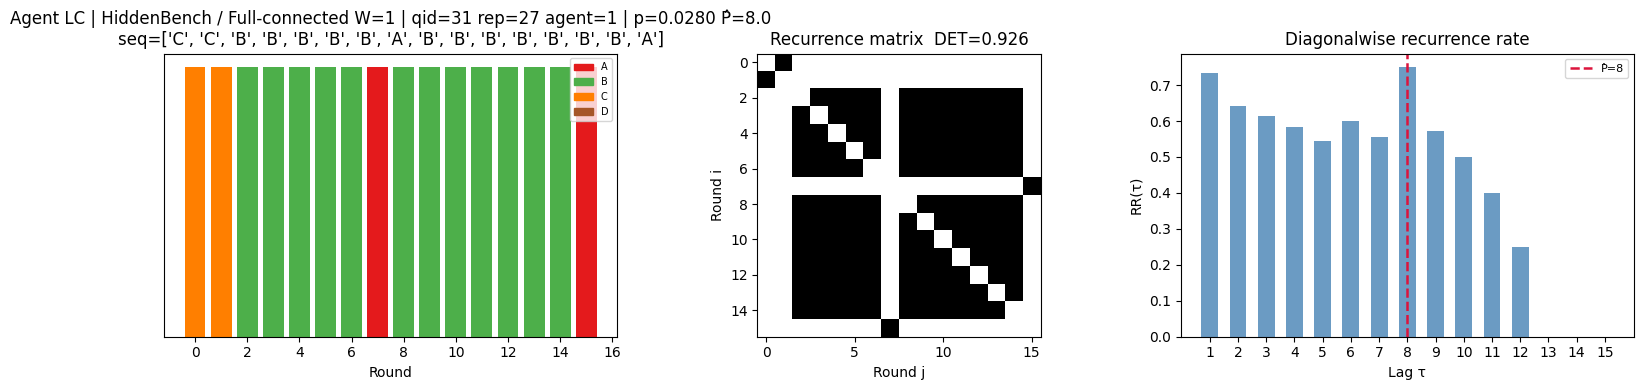

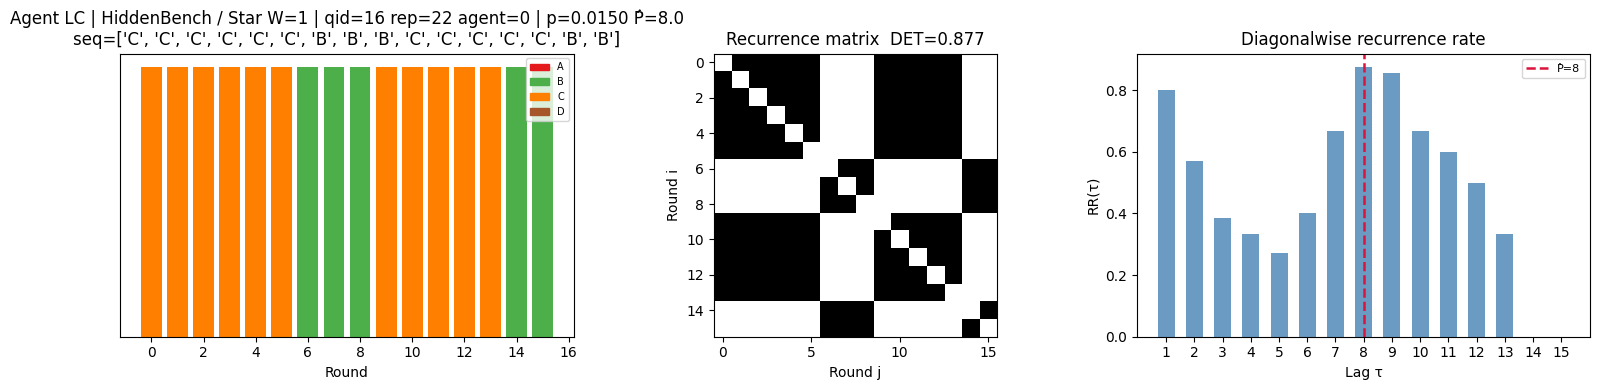

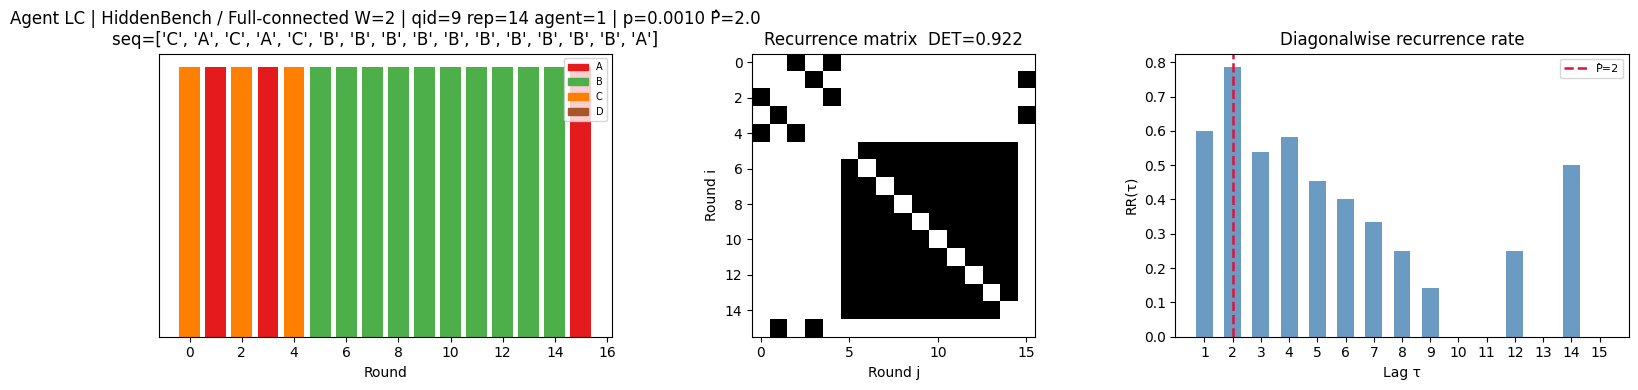

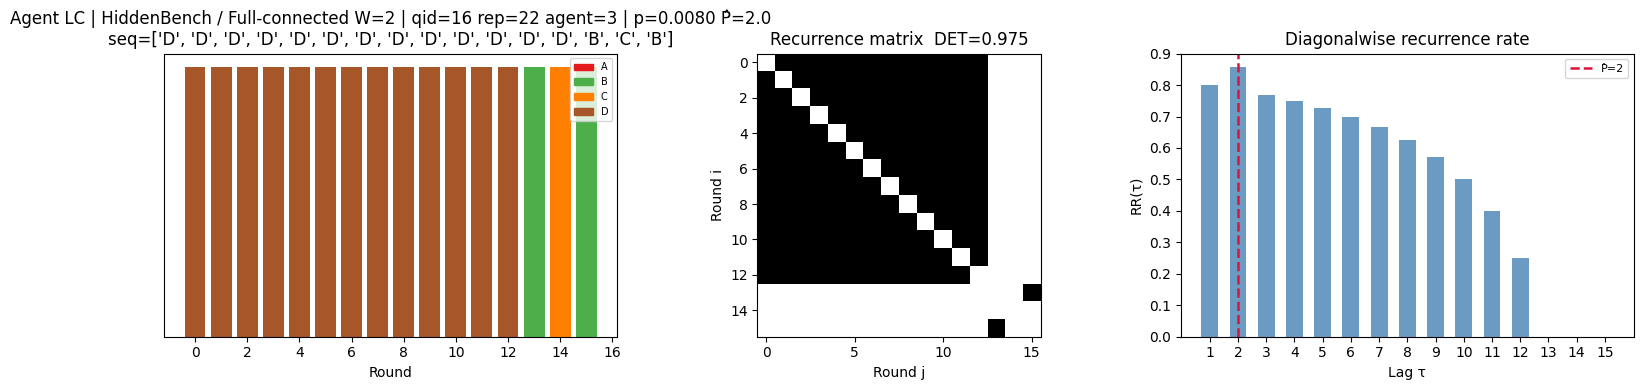

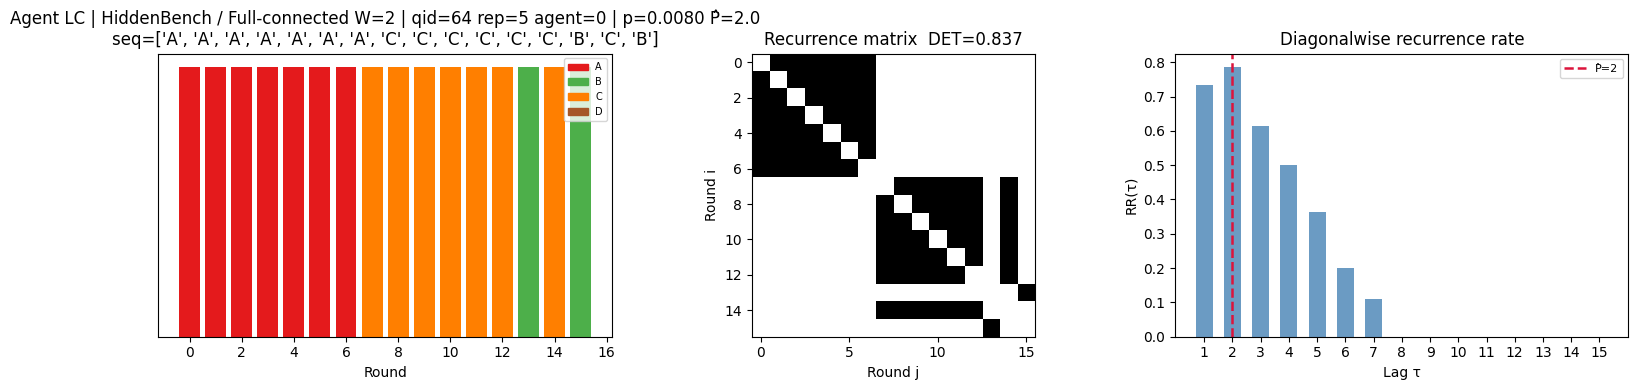

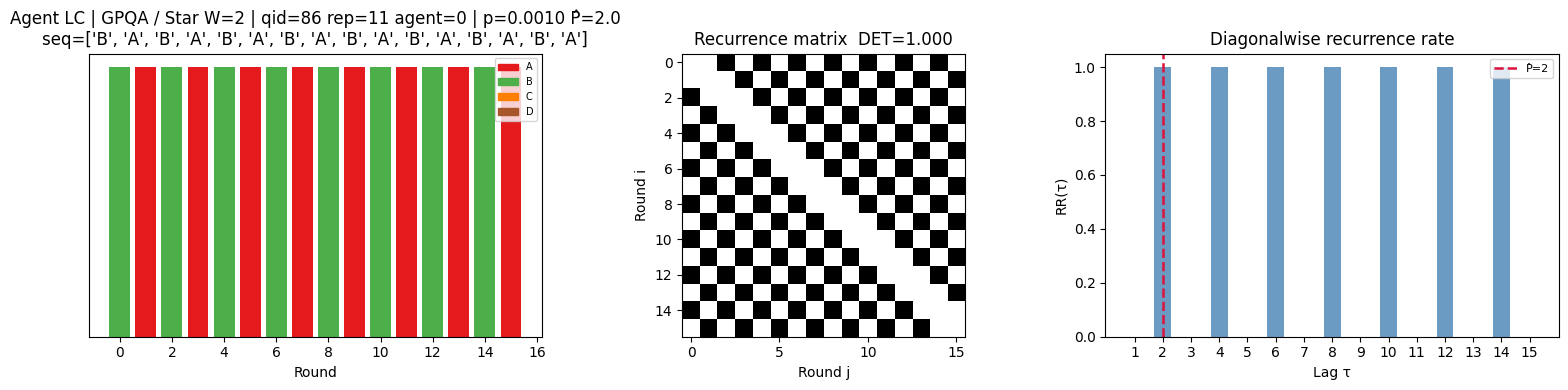

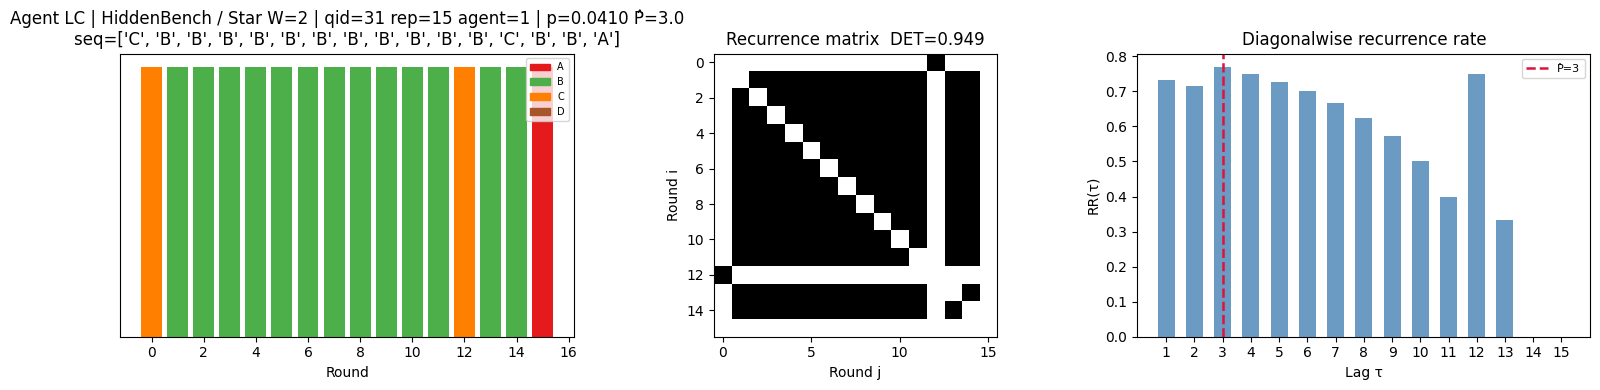

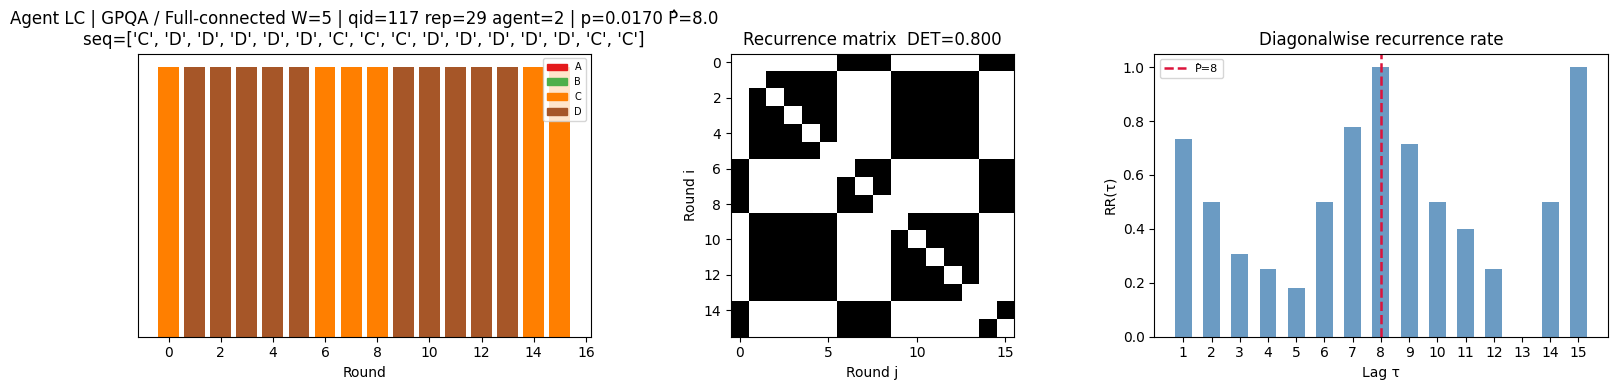

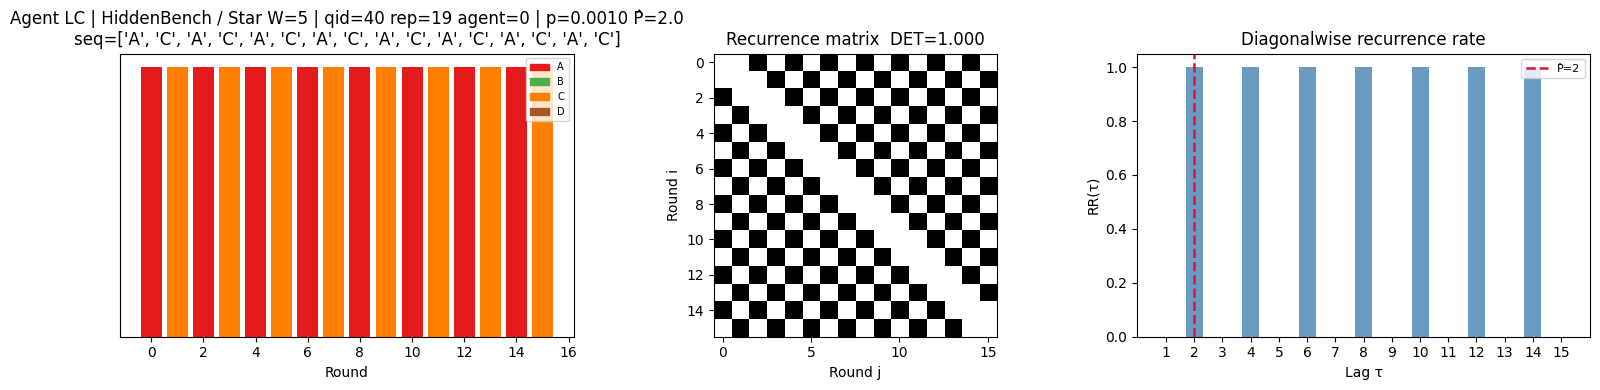

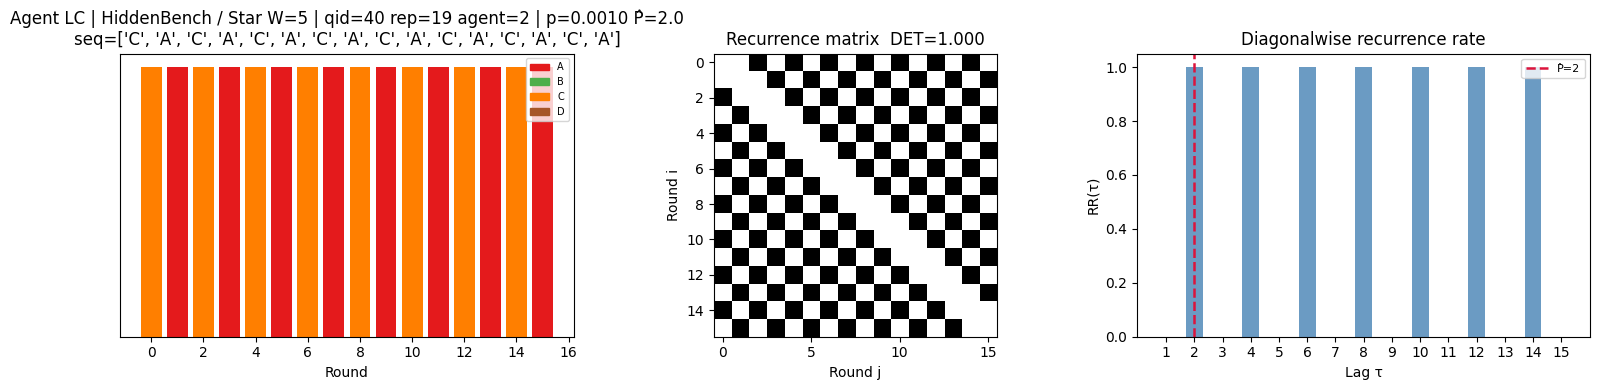

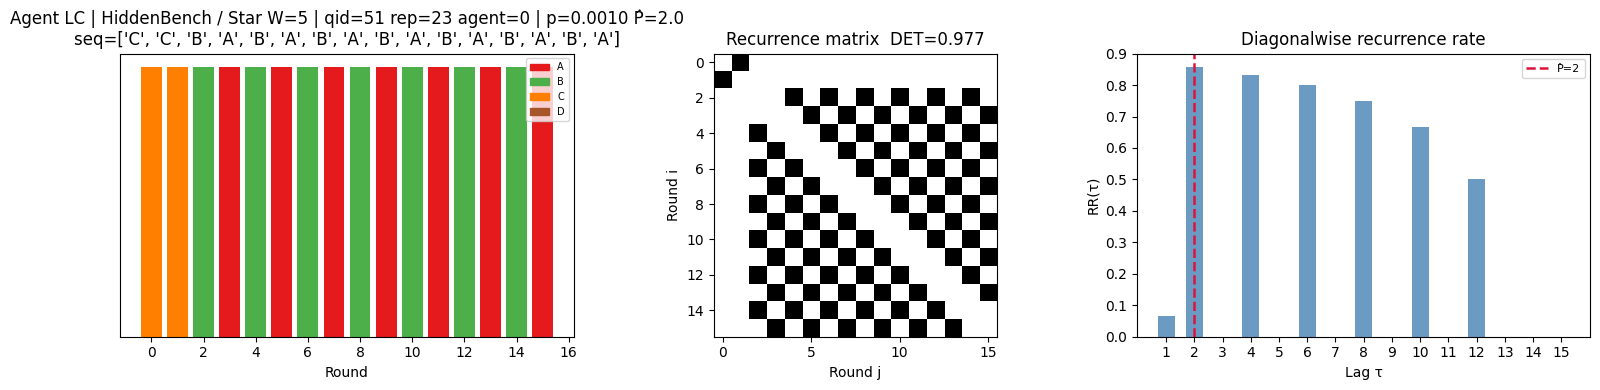

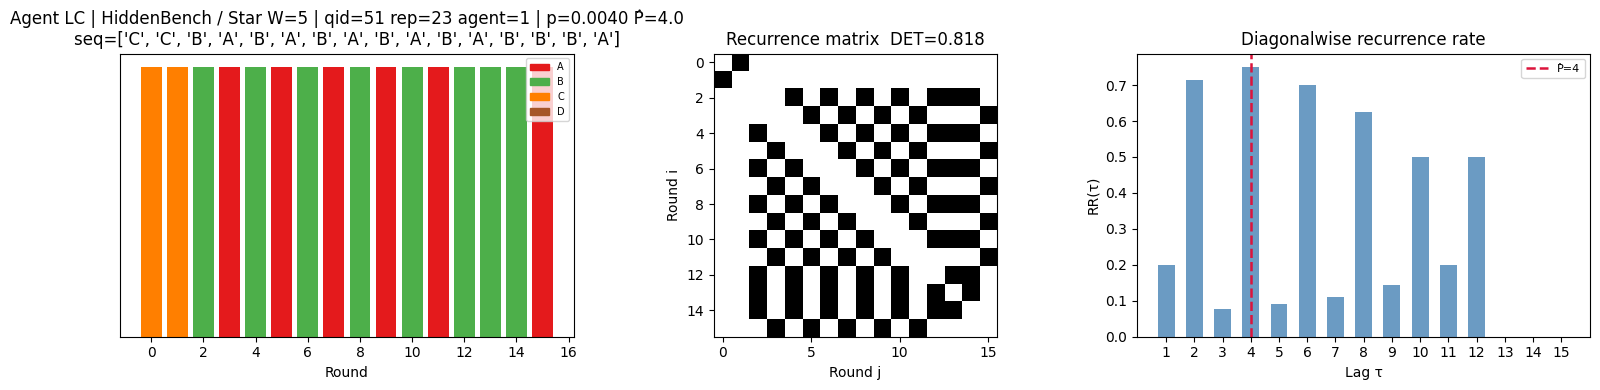

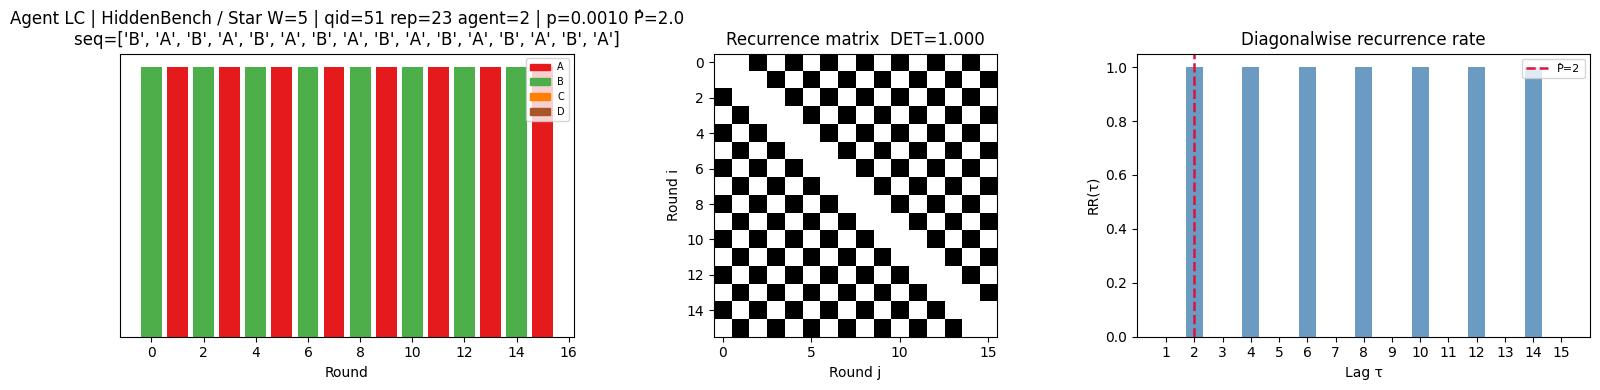

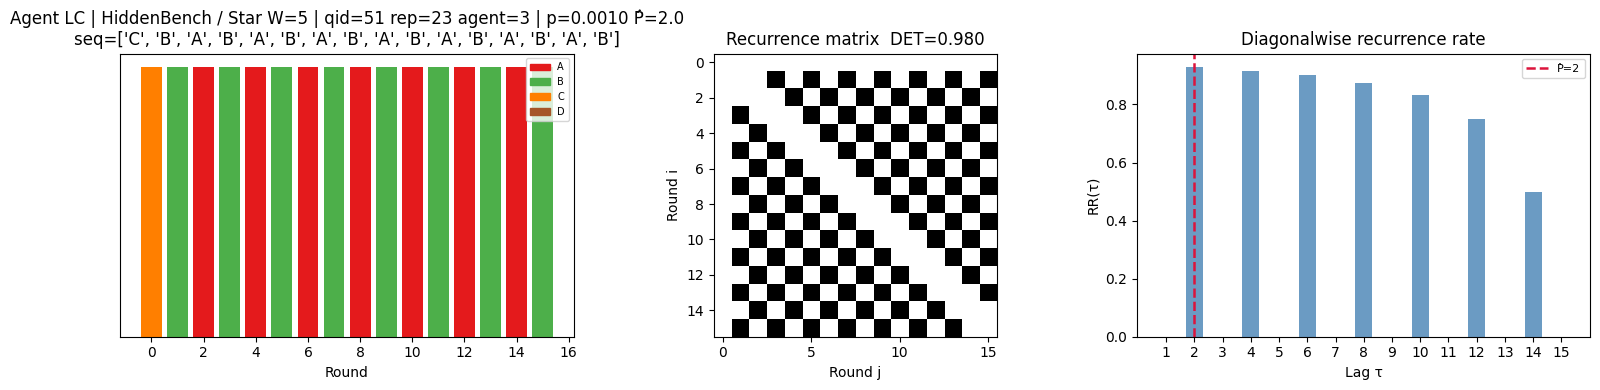

In [10]:
def plot_recurrence(seq, title, ax_seq, ax_rec, ax_rr):
    from src.metrics.limit_cycles import _recurrence_matrix, _diagonalwise_rr, _det

    L = len(seq)
    R = _recurrence_matrix(seq)
    rr = _diagonalwise_rr(R)
    det_val = _det(R)

    # sequence as color-coded bar
    vote_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
    if isinstance(seq[0], tuple):
        # system level: show as stacked bar (composition)
        opts = ['A', 'B', 'C', 'D']
        bottoms = np.zeros(L)
        colors  = ['#4C72B0','#DD8452','#55A868','#c44e52']
        for i, (opt, col) in enumerate(zip(opts, colors)):
            vals = [s[i] for s in seq]
            ax_seq.bar(range(L), vals, bottom=bottoms, color=col,
                       label=opt, width=0.8)
            bottoms += np.array(vals, dtype=float)
        ax_seq.legend(fontsize=7, loc='upper right')
        ax_seq.set_ylabel('Agent count')
    else:
        cmap  = plt.cm.Set1
        codes = [vote_map.get(v, 0) for v in seq]
        ax_seq.bar(range(L), [1]*L, color=[cmap(c/4) for c in codes], width=0.8)
        handles = [mpatches.Patch(color=cmap(i/4), label=v)
                   for i, v in enumerate(['A','B','C','D'])]
        ax_seq.legend(handles=handles, fontsize=7, loc='upper right')
        ax_seq.set_yticks([])
    ax_seq.set_xlabel('Round')
    ax_seq.set_title(f'{title}\nseq={list(seq) if not isinstance(seq[0],tuple) else seq}')

    # recurrence matrix
    ax_rec.imshow(R.astype(int), cmap='Greys', origin='upper', aspect='equal')
    ax_rec.set_xlabel('Round j')
    ax_rec.set_ylabel('Round i')
    ax_rec.set_title(f'Recurrence matrix  DET={det_val:.3f}')

    # diagonalwise RR
    taus = np.arange(1, L)
    ax_rr.bar(taus, rr, color='steelblue', alpha=0.8, width=0.6)
    if len(rr):
        P_hat = int(np.argmax(rr)) + 1
        ax_rr.axvline(P_hat, color='crimson', linewidth=1.8,
                      linestyle='--', label=f'P̂={P_hat}')
        ax_rr.legend(fontsize=8)
    ax_rr.set_xlabel('Lag τ')
    ax_rr.set_ylabel('RR(τ)')
    ax_rr.set_title('Diagonalwise recurrence rate')
    ax_rr.set_xticks(taus)


# ── Agent-level flagged ───────────────────────────────────────────────────────
flagged_agent = agent_df[agent_df['lc']].reset_index(drop=True)
print(f'Flagged agent-level cases: {len(flagged_agent)}')

if len(flagged_agent) == 0:
    print('No flagged agent-level limit cycles in the dataset.')
    print('This is consistent with the near-null prediction from the LaTeX spec.')
else:
    for _, row in flagged_agent.iterrows():
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        ttl = (f"Agent LC | {DS_LABELS[row['dataset']]} / {T_LABELS[row['topology']]} "
               f"W={row['W']} | qid={row['qid']} rep={row['rep_idx']} "
               f"agent={row['agent_idx']} | p={row['p_value']:.4f} P̂={row['period']}")
        plot_recurrence(row['seq'], ttl, axes[0], axes[1], axes[2])
        plt.tight_layout()
        plt.show()

Flagged system-level cases: 16


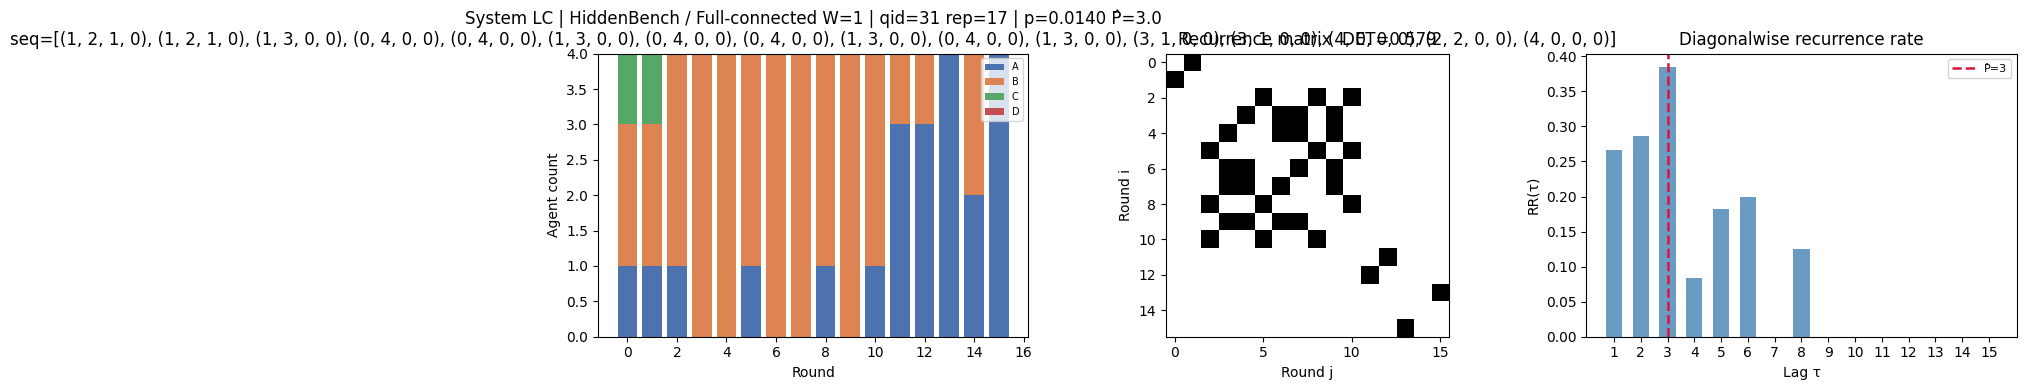

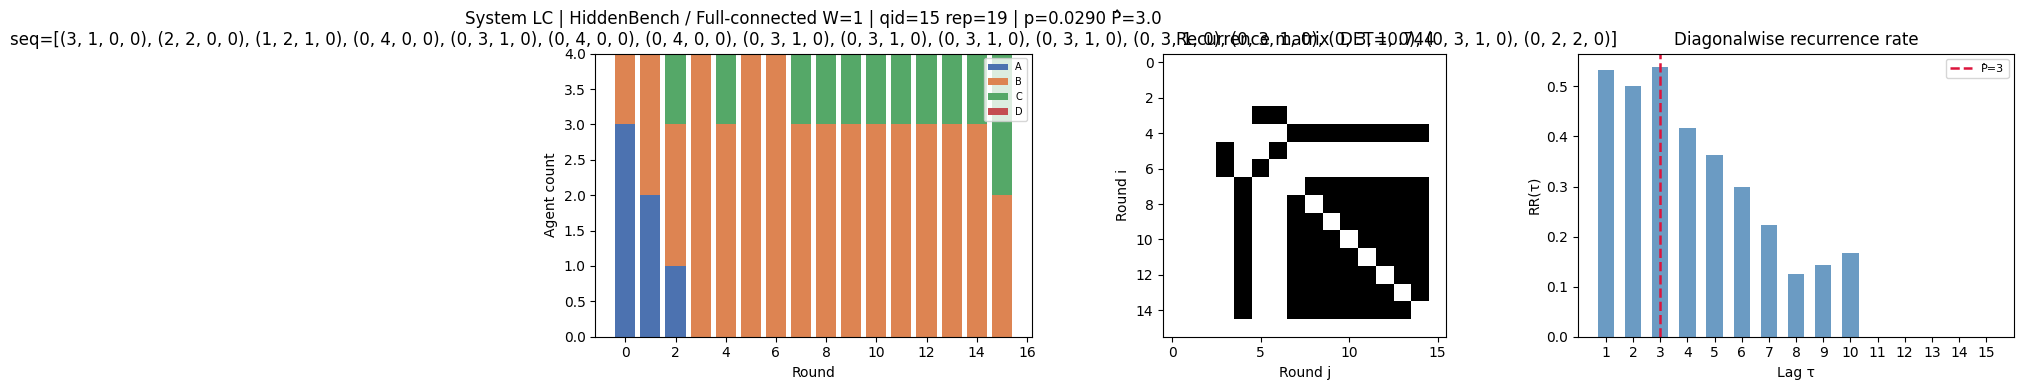

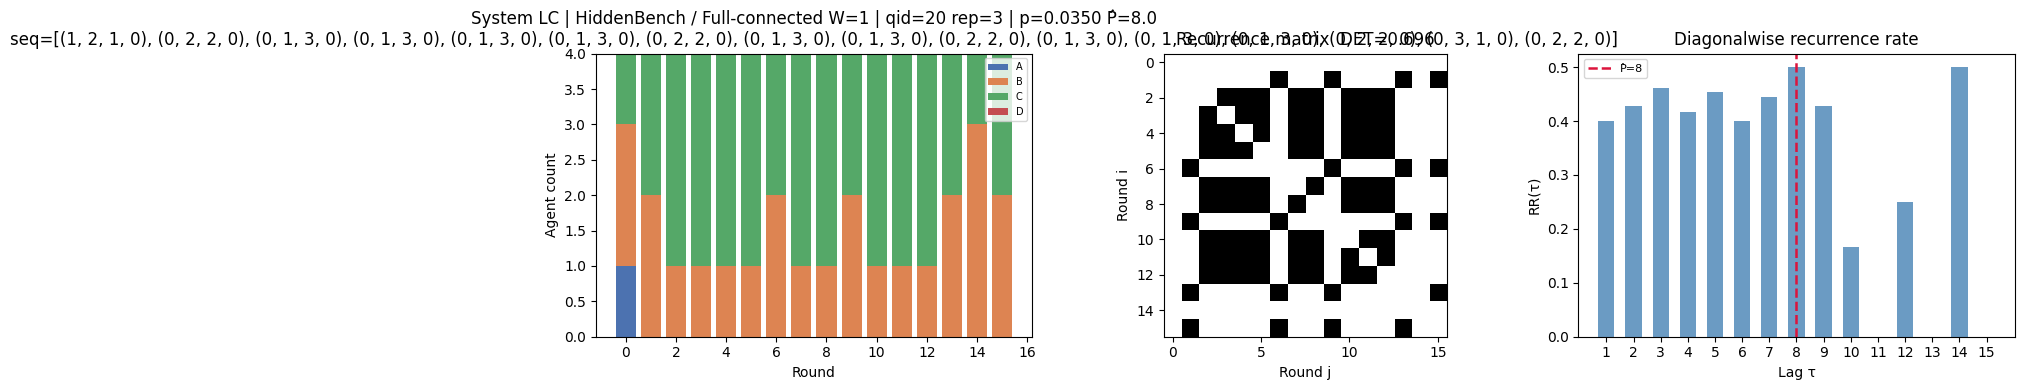

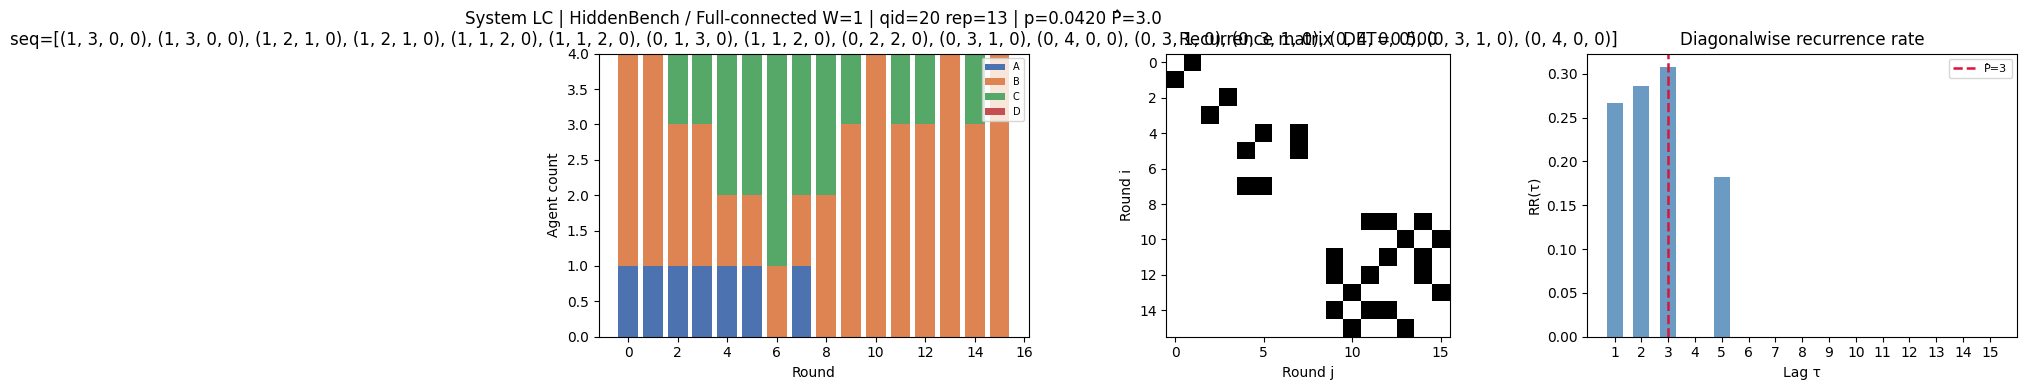

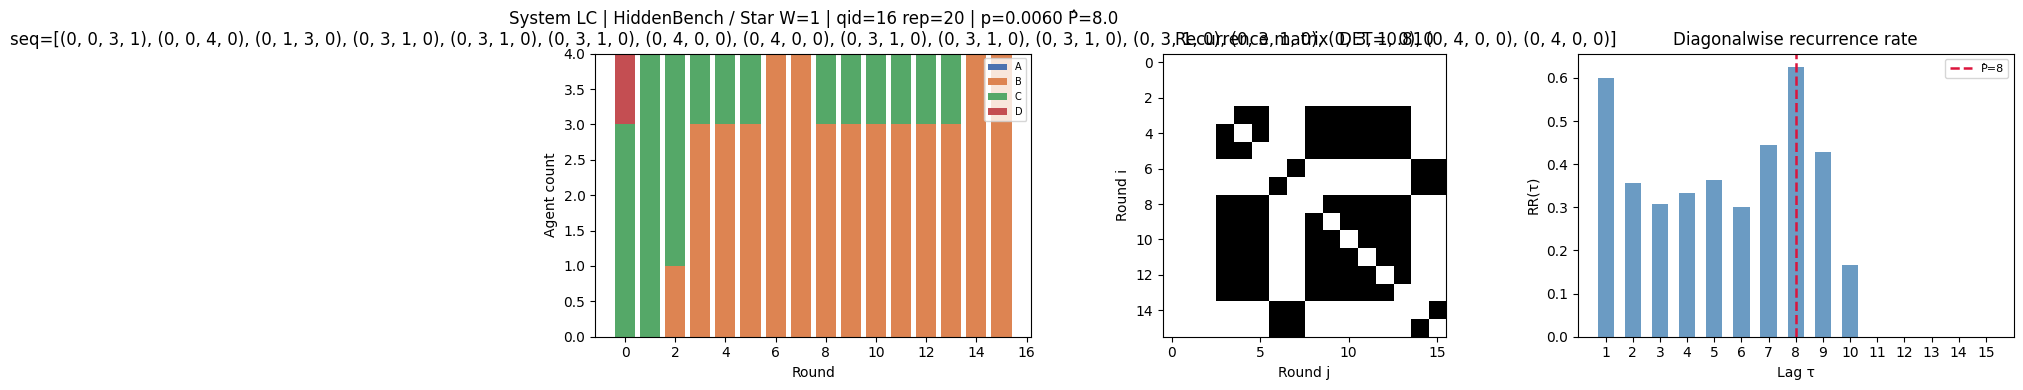

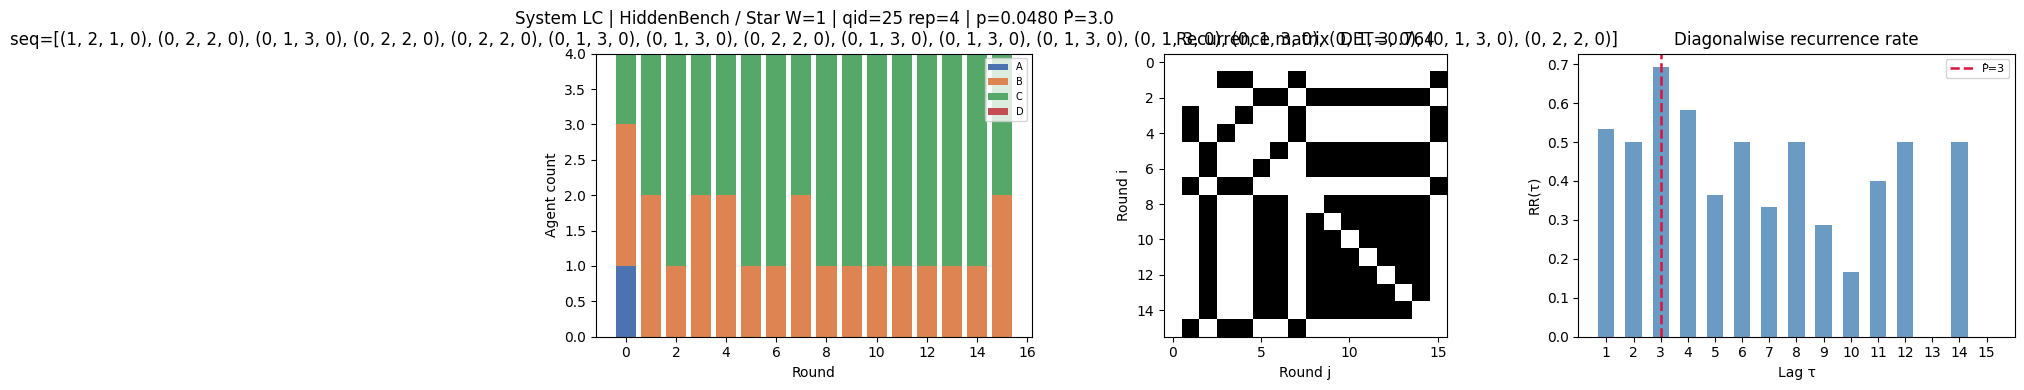

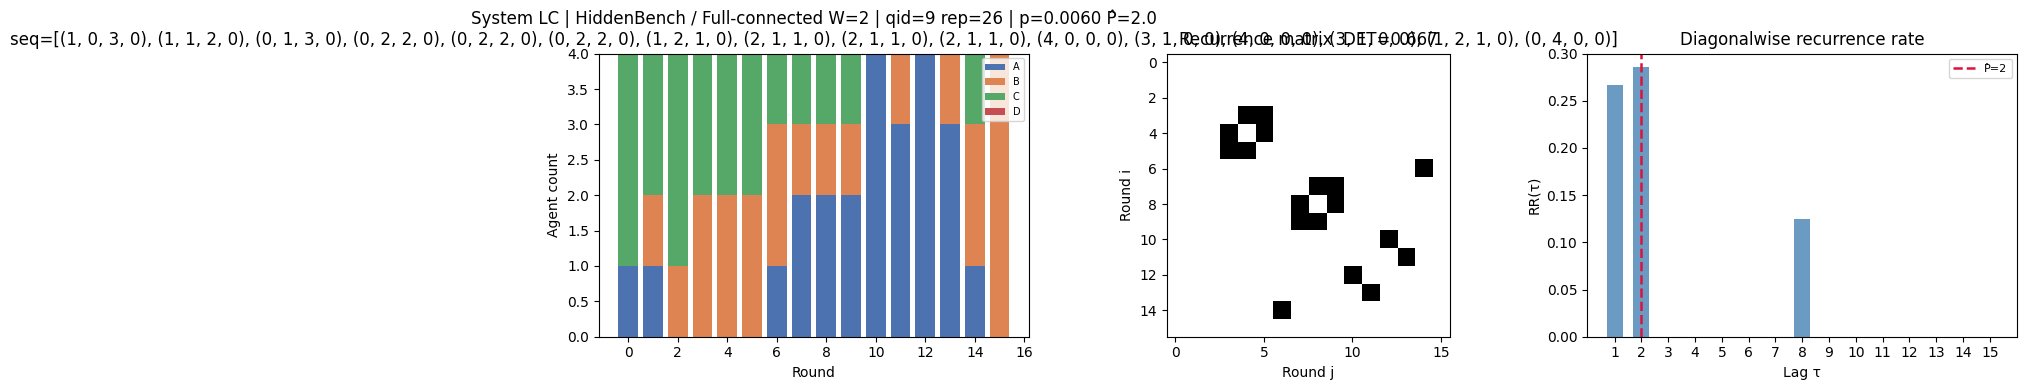

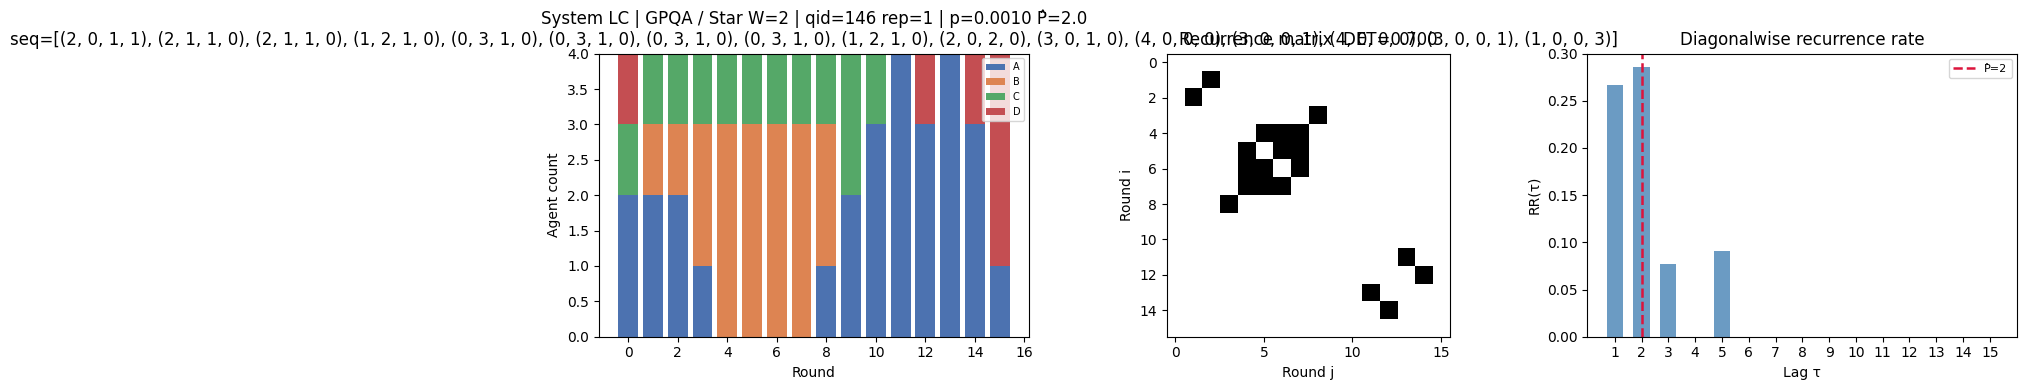

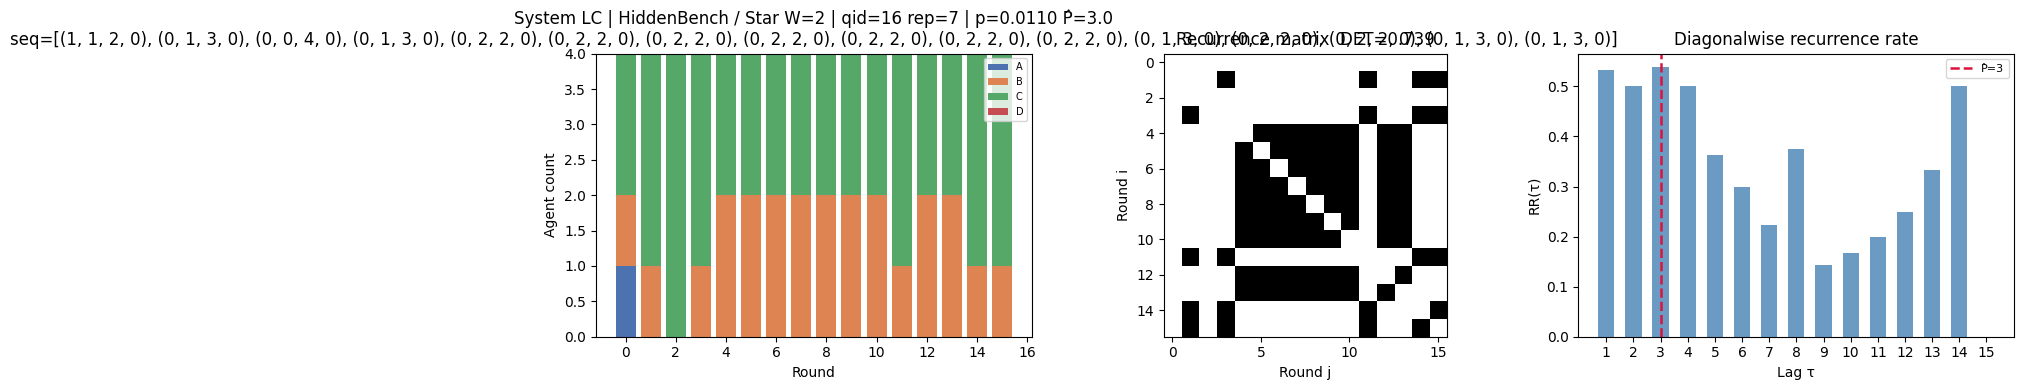

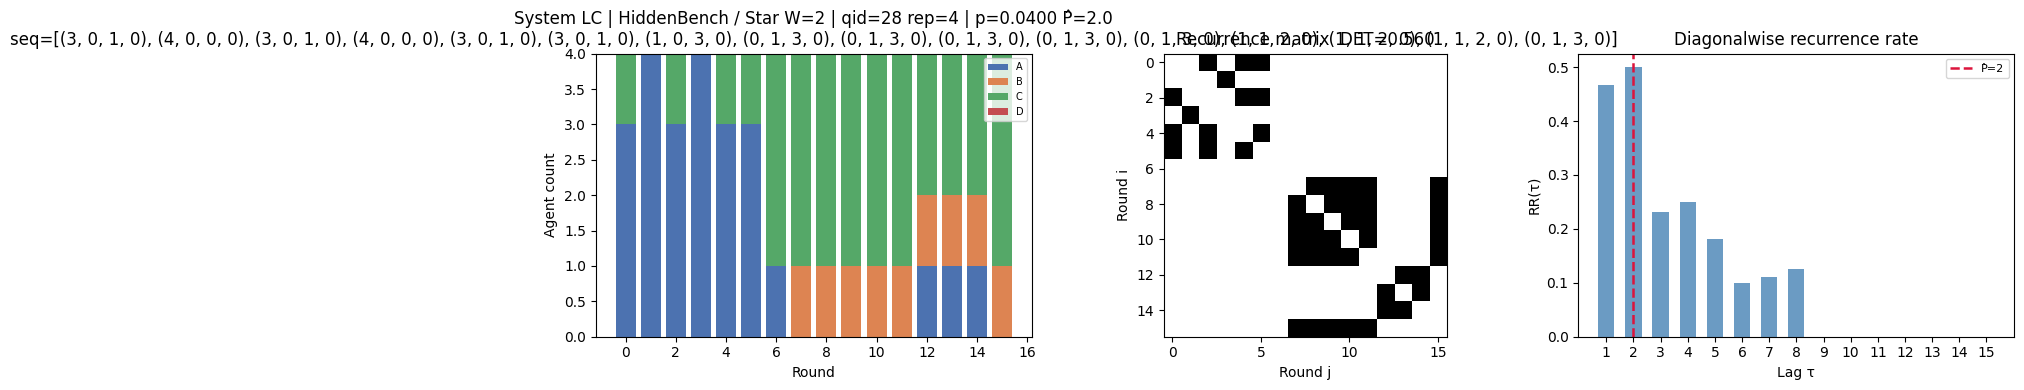

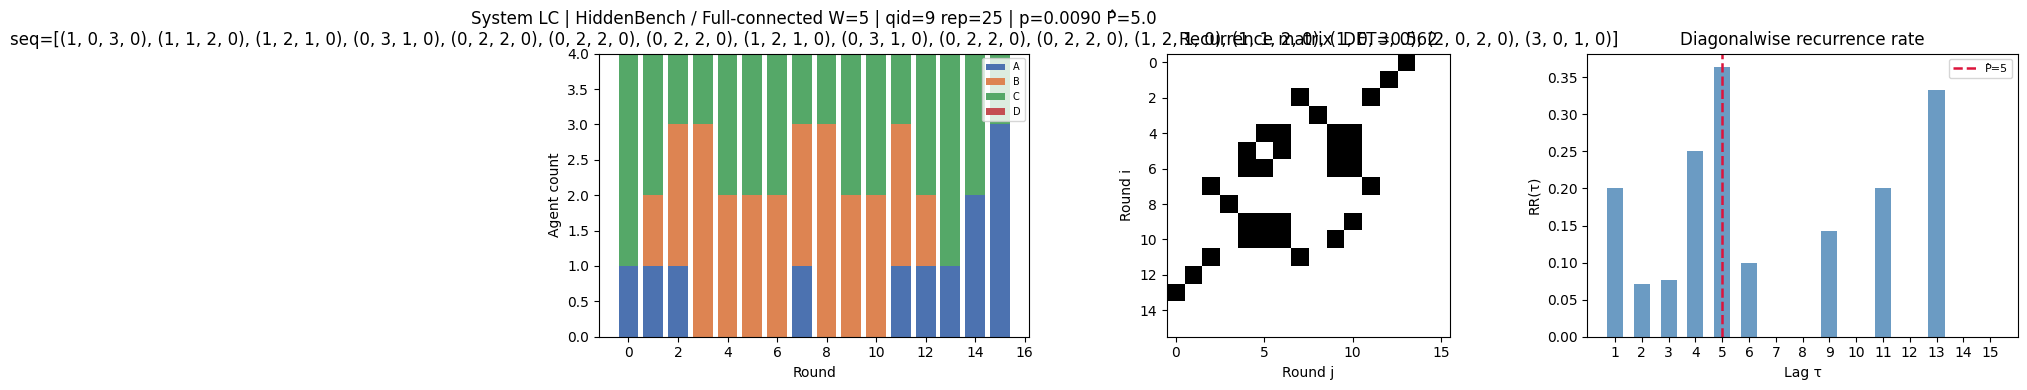

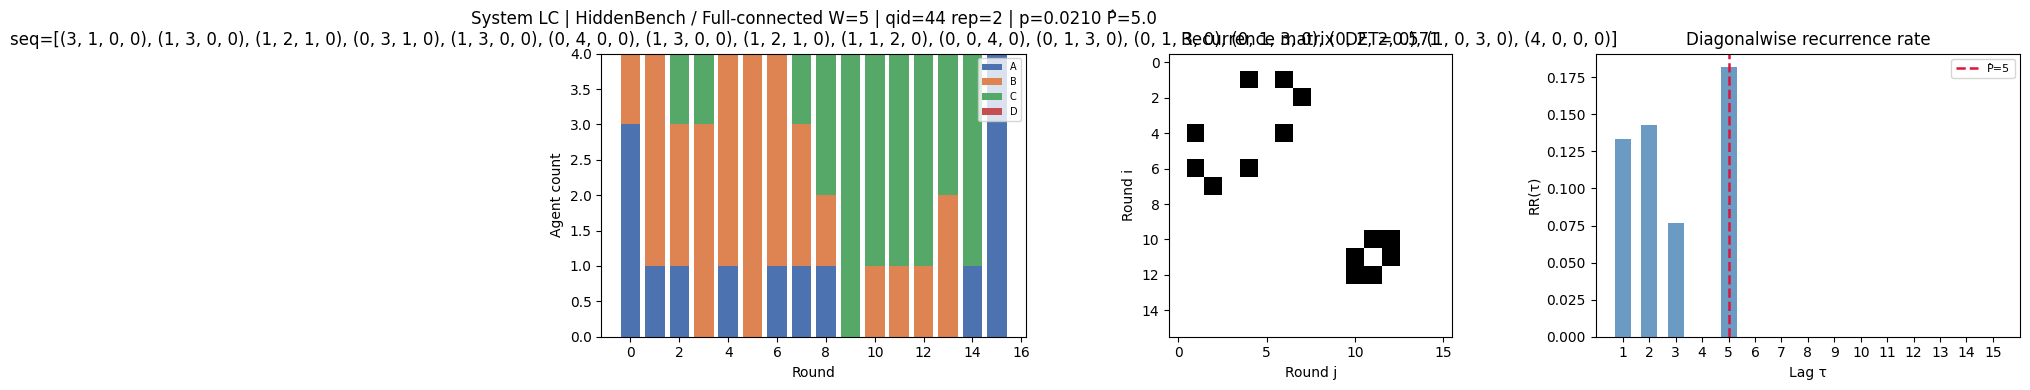

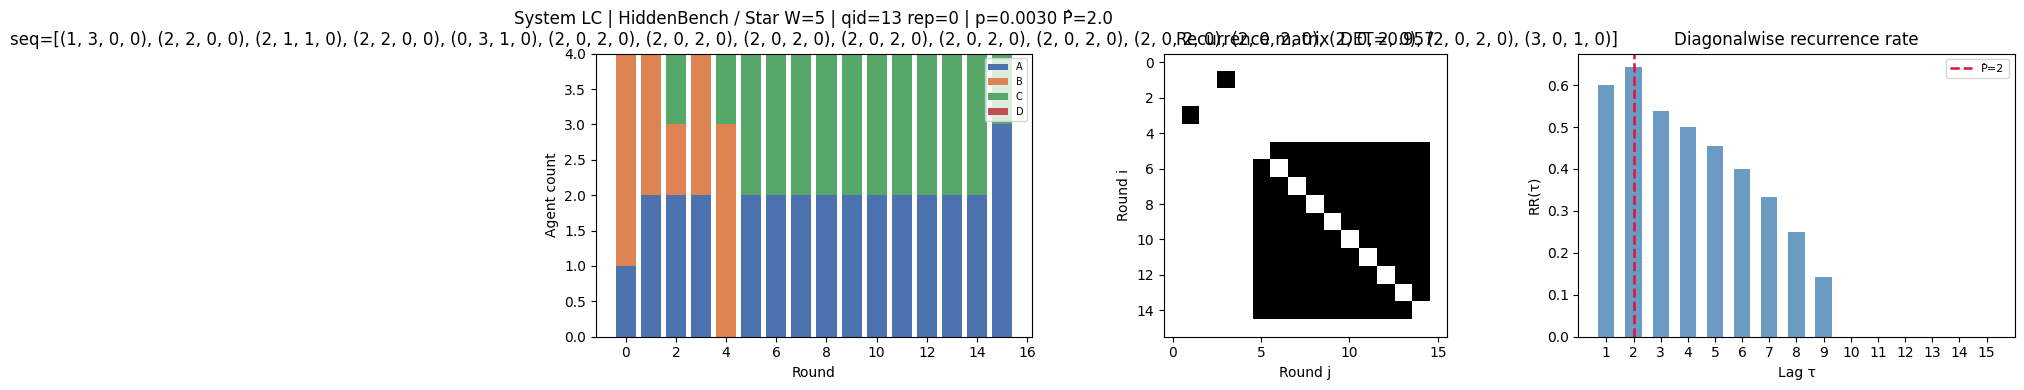

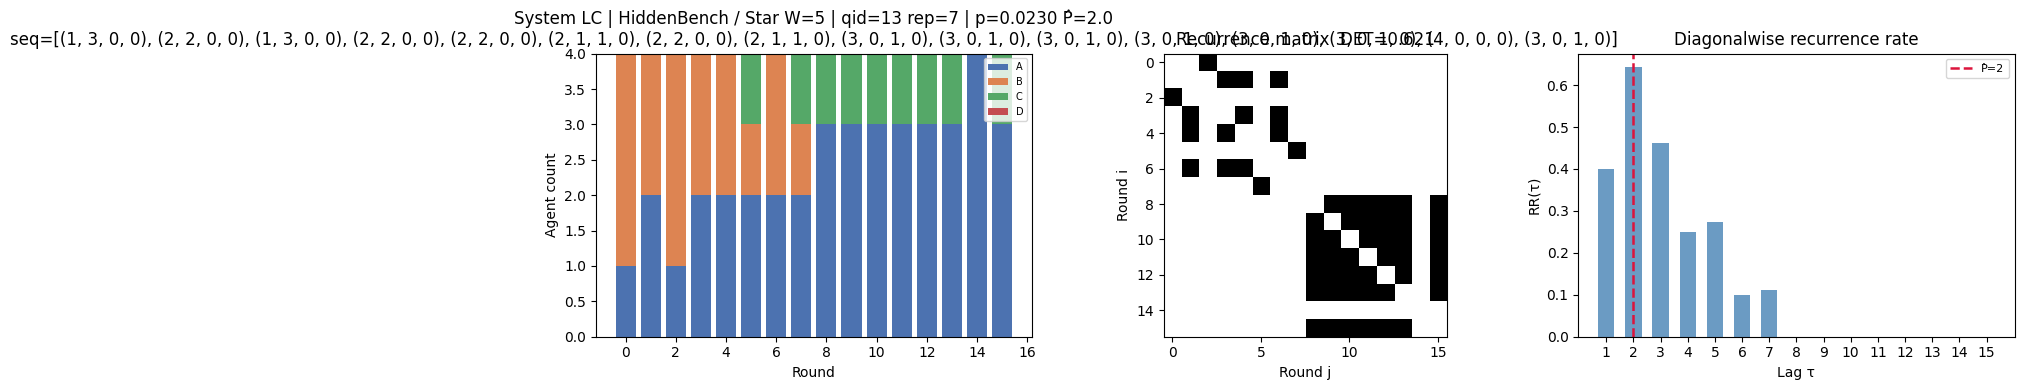

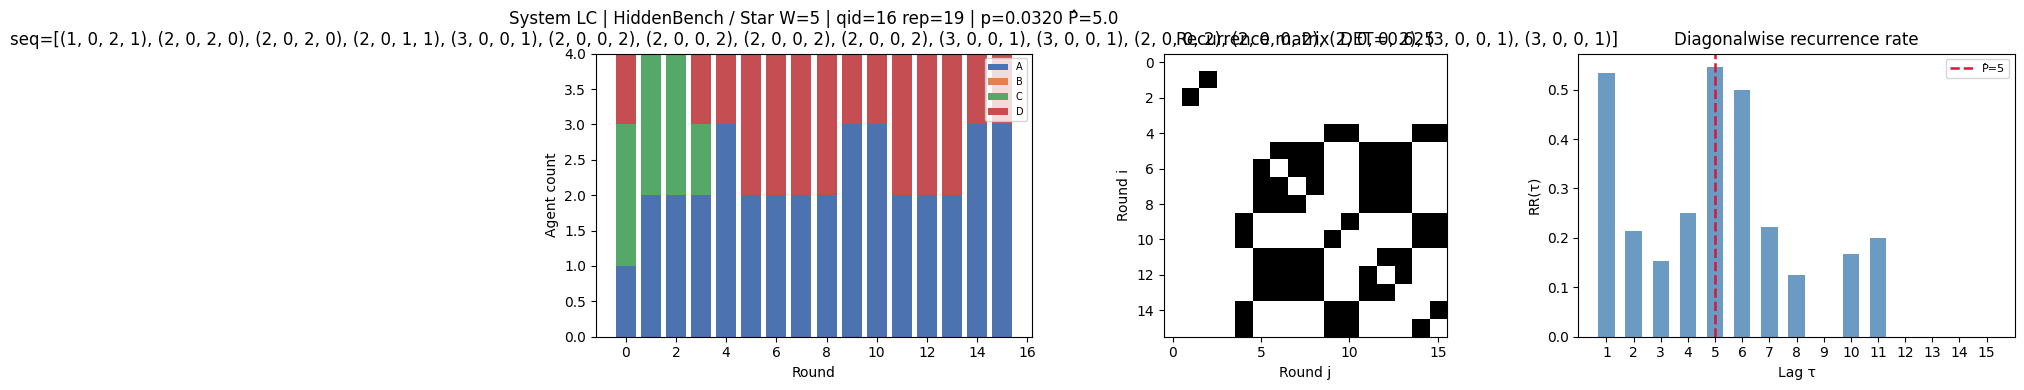

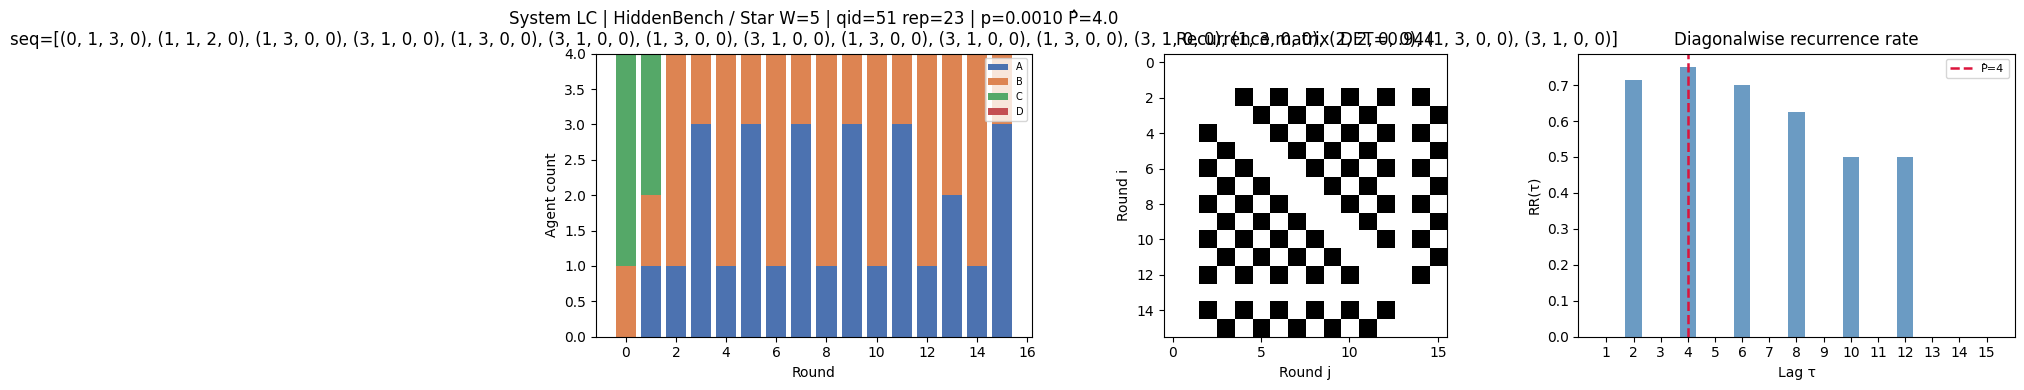

In [11]:
# ── System-level flagged ──────────────────────────────────────────────────────
flagged_sys = sys_df[sys_df['lc']].reset_index(drop=True)
print(f'Flagged system-level cases: {len(flagged_sys)}')

if len(flagged_sys) == 0:
    print('No flagged system-level limit cycles in the dataset.')
    print('This is consistent with the near-null prediction from the LaTeX spec.')
else:
    for _, row in flagged_sys.iterrows():
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        ttl = (f"System LC | {DS_LABELS[row['dataset']]} / {T_LABELS[row['topology']]} "
               f"W={row['W']} | qid={row['qid']} rep={row['rep_idx']} "
               f"| p={row['p_value']:.4f} P̂={row['period']}")
        plot_recurrence(row['seq'], ttl, axes[0], axes[1], axes[2])
        plt.tight_layout()
        plt.show()

---
## Part 5 — All Candidate Sequences (non-converged, unflagged)

Even unflagged candidates are interesting: they failed to converge but didn't have a periodic signature. Show their vote sequences.

In [12]:
# Summary of candidate sequences (all, flagged or not)
for df, label in [(agent_df, 'Agent'), (sys_df, 'System')]:
    cands = df[~df['fixed_point'] & (df['L'] >= 4)].copy()
    if len(cands) == 0:
        print(f'{label}: no candidates.')
        continue
    print(f'{label}-level candidates (n={len(cands)})')
    print(cands[['dataset','topology','W','qid','rep_idx',
                  'L','det','p_value','period','lc']].to_string(index=False))
    print()
    print('  Vote sequences:')
    for _, row in cands.iterrows():
        tag = ' ← FLAGGED LC' if row['lc'] else ''
        det_str = f"DET={row['det']:.3f}" if pd.notna(row['det']) else 'DET=n/a'
        p_str   = f"p={row['p_value']:.4f}" if pd.notna(row['p_value']) else 'p=n/a'
        if isinstance(row['seq'][0], tuple):
            seq_str = ' '.join(str(s) for s in row['seq'])
        else:
            seq_str = ''.join(row['seq'])
        print(f"    [{DS_LABELS[row['dataset']]} {row['topology']} W={row['W']} "
              f"q={row['qid']} r={row['rep_idx']}] "
              f"L={row['L']}  {det_str}  {p_str}  seq={seq_str}{tag}")
    print()

Agent-level candidates (n=500)
    dataset topology  W qid  rep_idx  L      det  p_value  period    lc
hiddenbench       fc  1   8        8 16 0.847222 0.139860     NaN False
hiddenbench       fc  1   8        8 16 0.684211 0.295704     NaN False
hiddenbench       fc  1   8        9 16 0.696429 0.233766     NaN False
hiddenbench       fc  1   8       12 16 0.888889 0.052947     NaN False
hiddenbench       fc  1   8       13 16 0.661538 0.926074     NaN False
hiddenbench       fc  1   8       14 16 0.800000 0.085914     NaN False
hiddenbench       fc  1   8       18 16 0.945652 0.285714     NaN False
hiddenbench       fc  1   8       26 16 0.902174 0.667333     NaN False
hiddenbench       fc  1   8       26 16 0.847222 0.176823     NaN False
hiddenbench       fc  1   8       26 16 0.802469 0.716284     NaN False
hiddenbench       fc  1  13       18 16 0.990476 0.117882     NaN False
hiddenbench       fc  1  24       23 16 0.728814 0.258741     NaN False
hiddenbench       fc  1  24      

---
## Part 6 — Cross-Level Comparison

For the same repetition, can an agent-level cycle and a system-level cycle co-occur?
Also: are the two non-convergence rates correlated across configs?

In [16]:
# Join on (dataset, topology, W, qid, rep_idx) to find co-occurring flags
agent_flag_keys = set(
    agent_df[agent_df['lc']]
    .apply(lambda r: (r['dataset'],r['topology'],r['W'],r['qid'],r['rep_idx']), axis=1)
)
sys_flag_keys = set(
    sys_df[sys_df['lc']]
    .apply(lambda r: (r['dataset'],r['topology'],r['W'],r['qid'],r['rep_idx']), axis=1)
)
both = agent_flag_keys & sys_flag_keys
print(f'Reps with AGENT-level LC flag : {len(agent_flag_keys)}')
print(f'Reps with SYSTEM-level LC flag: {len(sys_flag_keys)}')
print(f'Reps with BOTH flags          : {len(both)}')
if both:
    print('  Keys:', both)

Reps with AGENT-level LC flag : 10
Reps with SYSTEM-level LC flag: 16
Reps with BOTH flags          : 1
  Keys: {('hiddenbench', 'star', 5, '51', 23)}


In [18]:
agent_df[(agent_df['dataset']=='hiddenbench') & 
         (agent_df['topology']=='star') & 
         (agent_df['W']==5) & 
         (agent_df['qid']=='51') & 
         (agent_df['rep_idx']==23)][['agent_idx','lc','period','seq']]


,agent_idx,lc,period,seq
49772,0,True,2.0,"[C, C, B, A, B, A, B, A, B, A, B, A, B, A, B, A]"
49773,1,True,4.0,"[C, C, B, A, B, A, B, A, B, A, B, A, B, B, B, A]"
49774,2,True,2.0,"[B, A, B, A, B, A, B, A, B, A, B, A, B, A, B, A]"
49775,3,True,2.0,"[C, B, A, B, A, B, A, B, A, B, A, B, A, B, A, B]"


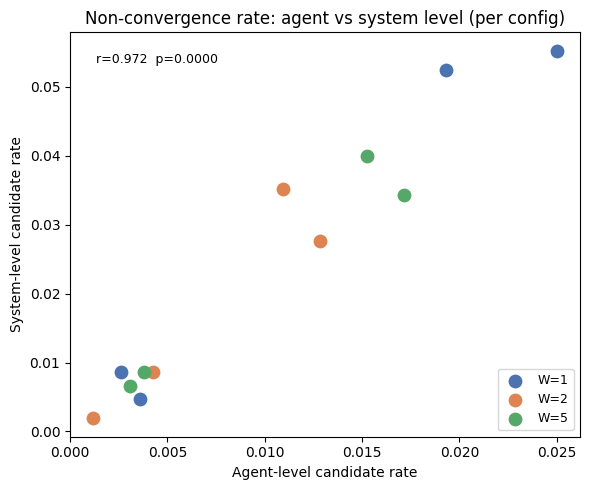

    Dataset       Topology  W  p_cand_agent  p_cand_sys
       GPQA Full-connected  1      0.003571    0.004762
       GPQA Full-connected  2      0.001190    0.001905
       GPQA Full-connected  5      0.003095    0.006667
       GPQA           Star  1      0.002619    0.008571
       GPQA           Star  2      0.004286    0.008571
       GPQA           Star  5      0.003810    0.008571
HiddenBench Full-connected  1      0.019286    0.052381
HiddenBench Full-connected  2      0.012857    0.027619
HiddenBench Full-connected  5      0.017143    0.034286
HiddenBench           Star  1      0.025000    0.055238
HiddenBench           Star  2      0.010952    0.035238
HiddenBench           Star  5      0.015238    0.040000


In [17]:
# Candidate rate correlation: agent-level p_cand vs system-level p_cand, per config
a_tab = atab.rename(columns={'p_LC': 'p_LC_agent', 'n_cand': 'n_cand_agent',
                              'n_total': 'n_total_agent'})
s_tab = stab.rename(columns={'p_LC': 'p_LC_sys',   'n_cand': 'n_cand_sys',
                              'n_total': 'n_total_sys'})
a_tab['p_cand_agent'] = a_tab['n_cand_agent'] / a_tab['n_total_agent']
s_tab['p_cand_sys']   = s_tab['n_cand_sys']   / s_tab['n_total_sys']

merged = a_tab[['Dataset','Topology','W','p_cand_agent']].merge(
    s_tab[['Dataset','Topology','W','p_cand_sys']],
    on=['Dataset','Topology','W'])

fig, ax = plt.subplots(figsize=(6, 5))
for w in W_VALUES:
    sub = merged[merged['W']==w]
    ax.scatter(sub['p_cand_agent'], sub['p_cand_sys'],
               color=W_COLORS[w], s=80, label=f'W={w}', zorder=3)

if merged['p_cand_agent'].std() > 0 and merged['p_cand_sys'].std() > 0:
    r, p = sp_stats.pearsonr(merged['p_cand_agent'], merged['p_cand_sys'])
    ax.text(0.05, 0.95, f'r={r:.3f}  p={p:.4f}', transform=ax.transAxes,
            fontsize=9, va='top')

ax.set_xlabel('Agent-level candidate rate')
ax.set_ylabel('System-level candidate rate')
ax.set_title('Non-convergence rate: agent vs system level (per config)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(merged.to_string(index=False))

---
## Part 7 — Summary & Findings

In [19]:
print('=== LIMIT CYCLE ANALYSIS — SUMMARY ===')
print()

# Agent level
a_total   = len(agent_df)
a_fp      = int(agent_df['fixed_point'].sum())
a_cand    = int((~agent_df['fixed_point'] & (agent_df['L'] >= 4)).sum())
a_flagged = int(agent_df['lc'].sum())

print('AGENT-LEVEL')
print(f'  Total agent sequences  : {a_total:,}')
print(f'  Fixed points           : {a_fp:,}  ({100*a_fp/a_total:.1f}%)')
print(f'  Candidates             : {a_cand:,}  ({100*a_cand/a_total:.2f}%)')
print(f'  Flagged limit cycles   : {a_flagged}')
print(f'  p_LC (among candidates): {a_flagged/a_cand:.4f}' if a_cand else '  p_LC: n/a')
print()

# System level
s_total   = len(sys_df)
s_fp      = int(sys_df['fixed_point'].sum())
s_cand    = int((~sys_df['fixed_point'] & (sys_df['L'] >= 4)).sum())
s_flagged = int(sys_df['lc'].sum())

print('SYSTEM-LEVEL')
print(f'  Total repetitions      : {s_total:,}')
print(f'  Fixed points           : {s_fp:,}  ({100*s_fp/s_total:.1f}%)')
print(f'  Candidates             : {s_cand:,}  ({100*s_cand/s_total:.2f}%)')
print(f'  Flagged limit cycles   : {s_flagged}')
print(f'  p_LC (among candidates): {s_flagged/s_cand:.4f}' if s_cand else '  p_LC: n/a')
print()

print('KEY FINDING')
if a_flagged == 0 and s_flagged == 0:
    print('  Both levels return a NEAR-NULL result: virtually all agent and')
    print('  system trajectories converge to fixed points. The cooperative,')
    print('  convergence-forced debate design suppresses limit cycles entirely.')
    print('  This is a valid and expected finding, consistent with the LaTeX spec.')
elif a_flagged > 0 or s_flagged > 0:
    print(f'  {a_flagged} agent-level and {s_flagged} system-level limit cycles')
    print('  were detected. See Part 4 for per-case recurrence plots.')

=== LIMIT CYCLE ANALYSIS — SUMMARY ===

AGENT-LEVEL
  Total agent sequences  : 50,400
  Fixed points           : 49,896  (99.0%)
  Candidates             : 500  (0.99%)
  Flagged limit cycles   : 14
  p_LC (among candidates): 0.0280

SYSTEM-LEVEL
  Total repetitions      : 12,600
  Fixed points           : 12,301  (97.6%)
  Candidates             : 298  (2.37%)
  Flagged limit cycles   : 16
  p_LC (among candidates): 0.0537

KEY FINDING
  14 agent-level and 16 system-level limit cycles
  were detected. See Part 4 for per-case recurrence plots.
